# Credit Card 数据集分箱对比实验

本 Notebook 对比 `scorecard` 模块和 `scorecard_legacy` 模块的分箱结果。

## 数据集说明
- creditcard.csv 是信用卡欺诈检测数据集
- 目标变量：Class (0=正常, 1=欺诈)
- 特征：V1-V28 (PCA降维后的特征), Amount (交易金额), Time (时间)

In [1]:
# 设置内核为 conda py311 环境
# 请确保在 Jupyter 中选择正确的内核: Python (py311)

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

# 添加项目路径
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
from IPython.display import display

print(f"Python 版本: {sys.version}")
print(f"Pandas 版本: {pd.__version__}")
print(f"NumPy 版本: {np.__version__}")

Python 版本: 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:56:31) [Clang 19.1.7 ]
Pandas 版本: 3.0.1
NumPy 版本: 1.26.0


## 1. 加载数据

In [3]:
# 加载 creditcard 数据集
df = pd.read_csv('../test/creditcard.csv')
print(f"数据集形状: {df.shape}")
print(f"\n目标变量分布:")
print(df['Class'].value_counts())
print(f"\n坏率: {df['Class'].mean():.4%}")
df.head()

数据集形状: (284807, 31)

目标变量分布:
Class
0    284315
1       492
Name: count, dtype: int64

坏率: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# 选择部分特征进行分箱测试（为了加快速度）
# 这里选择 V1-V10 和 Amount
target = 'Class'
features = ['V1', 'V2', 'V3', 'V4', 'V5', 'Amount']

print(f"目标变量: {target}")
print(f"待分箱特征: {features}")

目标变量: Class
待分箱特征: ['V1', 'V2', 'V3', 'V4', 'V5', 'Amount']


## 2. 使用 scorecard_legacy 模块进行分箱

In [5]:
from syriskmodels.scorecard_legacy import woebin as woebin_legacy
from syriskmodels.scorecard_legacy import sc_bins_to_df as sc_bins_to_df_legacy

In [6]:
%%time
# 使用 scorecard_legacy 进行分箱
# 默认方法: quantile + tree
bins_legacy = woebin_legacy(
    df, 
    y=target, 
    x=features,
    methods=['quantile', 'tree'],
    no_cores=1  # 单进程避免多进程问题
)

CPU times: user 1.58 s, sys: 94 ms, total: 1.67 s
Wall time: 1.81 s


In [7]:
# 查看分箱结果
woe_df_legacy, iv_df_legacy = sc_bins_to_df_legacy(bins_legacy)
print("=== scorecard_legacy 分箱结果 ===")
print("\nIV 汇总表:")
display(iv_df_legacy)

=== scorecard_legacy 分箱结果 ===

IV 汇总表:


,IV,IV区间,单调性,最大Lift,最小Lift
variable,,,,,
V4,3.735624,"[0.2, +)",increasing,14.433276,0.020325
V3,3.056649,"[0.2, +)",decreasing,14.762680,0.137583
V2,2.346762,"[0.2, +)",increasing,12.652361,0.263053
V1,1.480537,"[0.2, +)",decreasing,8.859518,0.067695
V5,1.183271,"[0.2, +)",decreasing,9.349167,0.560549
Amount,0.654037,"[0.2, +)",up_u_shape,2.787043,0.334133


In [8]:
# 查看单个变量的详细分箱结果
print("\nV1 变量分箱详情:")
display(bins_legacy['V1'][['variable', 'bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv', 'total_iv']])


V1 变量分箱详情:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv
0,V1,"[-inf,-2.899)",14244,0.050013,14026,218,0.015305,-2.195186,0.864370,1.480537
1,V1,"[-2.899,-1.893)",14239,0.049995,14181,58,0.004073,-0.860144,0.058497,1.480537
2,V1,"[-1.893,1.924)",213568,0.749869,213357,211,0.000988,0.559505,0.179916,1.480537
3,V1,"[1.924,inf)",42756,0.150123,42751,5,0.000117,2.694351,0.377754,1.480537


## 3. 使用 scorecard 模块进行分箱

In [9]:
from syriskmodels.scorecard import woebin as woebin_new
from syriskmodels.scorecard import sc_bins_to_df as sc_bins_to_df_new

In [10]:
%%time
# 使用 scorecard 模块进行分箱
# 相同的参数设置
bins_new = woebin_new(
    df, 
    y=target, 
    x=features,
    methods=['quantile', 'tree'],
    no_cores=1
)

CPU times: user 1.4 s, sys: 60.2 ms, total: 1.46 s
Wall time: 1.51 s


In [11]:
# 查看分箱结果
woe_df_new, iv_df_new = sc_bins_to_df_new(bins_new)
print("=== scorecard 模块分箱结果 ===")
print("\nIV 汇总表:")
display(iv_df_new)

=== scorecard 模块分箱结果 ===

IV 汇总表:


,IV,IV区间,单调性,最大Lift,最小Lift
variable,,,,,
V4,3.735624,"[0.2, +)",increasing,14.433276,0.020325
V3,3.056649,"[0.2, +)",decreasing,14.762680,0.137583
V2,2.346762,"[0.2, +)",increasing,12.652361,0.263053
V1,1.480537,"[0.2, +)",decreasing,8.859518,0.067695
V5,1.183271,"[0.2, +)",decreasing,9.349167,0.560549
Amount,0.654037,"[0.2, +)",up_u_shape,2.787043,0.334133


In [12]:
# 查看单个变量的详细分箱结果
print("\nV1 变量分箱详情:")
display(bins_new['V1'][['variable', 'bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv', 'total_iv']])


V1 变量分箱详情:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv
0,V1,"[-inf,-2.899)",14244,0.050013,14026,218,0.015305,-2.195186,0.864370,1.480537
1,V1,"[-2.899,-1.893)",14239,0.049995,14181,58,0.004073,-0.860144,0.058497,1.480537
2,V1,"[-1.893,1.924)",213568,0.749869,213357,211,0.000988,0.559505,0.179916,1.480537
3,V1,"[1.924,inf)",42756,0.150123,42751,5,0.000117,2.694351,0.377754,1.480537


## 4. 分箱结果对比

### 4.1 IV 值对比

In [13]:
# IV 值对比
iv_compare = pd.DataFrame({
    'variable': iv_df_legacy.index,
    'IV_legacy': iv_df_legacy['IV'].values,
    'IV_new': iv_df_new['IV'].values,
})
iv_compare['IV_diff'] = iv_compare['IV_new'] - iv_compare['IV_legacy']
iv_compare['IV_diff_pct'] = (iv_compare['IV_diff'] / iv_compare['IV_legacy'] * 100).round(4)

print("IV 值对比:")
display(iv_compare)

IV 值对比:


,variable,IV_legacy,IV_new,IV_diff,IV_diff_pct
0,V4,3.735624,3.735624,0.0,0.0
1,V3,3.056649,3.056649,0.0,0.0
2,V2,2.346762,2.346762,0.0,0.0
3,V1,1.480537,1.480537,0.0,0.0
4,V5,1.183271,1.183271,0.0,0.0
5,Amount,0.654037,0.654037,0.0,0.0


### 4.2 分箱数量对比

In [14]:
# 分箱数量对比
bin_count_compare = pd.DataFrame({
    'variable': features,
    'bins_legacy': [len(bins_legacy[v]) for v in features],
    'bins_new': [len(bins_new[v]) for v in features],
})
bin_count_compare['bins_diff'] = bin_count_compare['bins_new'] - bin_count_compare['bins_legacy']

print("分箱数量对比:")
display(bin_count_compare)

分箱数量对比:


,variable,bins_legacy,bins_new,bins_diff
0,V1,4,4,0
1,V2,3,3,0
2,V3,3,3,0
3,V4,4,4,0
4,V5,2,2,0
5,Amount,4,4,0


### 4.3 分箱切分点对比

In [15]:
def compare_breaks(bins_legacy, bins_new, var_name):
    """对比单个变量的切分点"""
    # 提取切分点（非特殊值）
    breaks_legacy = bins_legacy[var_name][~bins_legacy[var_name]['is_special_values']]['breaks'].tolist()
    breaks_new = bins_new[var_name][~bins_new[var_name]['is_special_values']]['breaks'].tolist()
    
    print(f"\n=== {var_name} 切分点对比 ===")
    print(f"legacy 切分点 ({len(breaks_legacy)}): {breaks_legacy}")
    print(f"new 切分点 ({len(breaks_new)}): {breaks_new}")
    
    # 检查是否一致
    if set(breaks_legacy) == set(breaks_new):
        print("✓ 切分点完全一致")
    else:
        print("✗ 切分点存在差异")
        only_legacy = set(breaks_legacy) - set(breaks_new)
        only_new = set(breaks_new) - set(breaks_legacy)
        if only_legacy:
            print(f"  仅 legacy: {only_legacy}")
        if only_new:
            print(f"  仅 new: {only_new}")

for var in features:
    compare_breaks(bins_legacy, bins_new, var)


=== V1 切分点对比 ===
legacy 切分点 (4): ['-2.899', '-1.893', '1.924', 'inf']
new 切分点 (4): ['-2.899', '-1.893', '1.924', 'inf']
✓ 切分点完全一致

=== V2 切分点对比 ===
legacy 切分点 (3): ['1.11', '1.809', 'inf']
new 切分点 (3): ['1.11', '1.809', 'inf']
✓ 切分点完全一致

=== V3 切分点对比 ===
legacy 切分点 (3): ['-2.3899999999999997', '-0.3972', 'inf']
new 切分点 (3): ['-2.3899999999999997', '-0.3972', 'inf']
✓ 切分点完全一致

=== V4 切分点对比 ===
legacy 切分点 (4): ['-0.6962', '1.483', '2.5669999999999997', 'inf']
new 切分点 (4): ['-0.6962', '1.483', '2.5669999999999997', 'inf']
✓ 切分点完全一致

=== V5 切分点对比 ===
legacy 切分点 (2): ['-1.702', 'inf']
new 切分点 (2): ['-1.702', 'inf']
✓ 切分点完全一致

=== Amount 切分点对比 ===
legacy 切分点 (4): ['1.98', '8.91', '77.16', 'inf']
new 切分点 (4): ['1.98', '8.91', '77.16', 'inf']
✓ 切分点完全一致


### 4.4 WOE 值对比（以 V1 为例）

In [16]:
# WOE 值对比
var = 'V1'
woe_compare = pd.merge(
    bins_legacy[var][['bin', 'count', 'badprob', 'woe', 'bin_iv']].rename(columns={
        'count': 'count_legacy',
        'badprob': 'badprob_legacy',
        'woe': 'woe_legacy',
        'bin_iv': 'bin_iv_legacy'
    }),
    bins_new[var][['bin', 'count', 'badprob', 'woe', 'bin_iv']].rename(columns={
        'count': 'count_new',
        'badprob': 'badprob_new',
        'woe': 'woe_new',
        'bin_iv': 'bin_iv_new'
    }),
    on='bin',
    how='outer'
)

woe_compare['woe_diff'] = (woe_compare['woe_new'] - woe_compare['woe_legacy']).abs()
woe_compare['badprob_diff'] = (woe_compare['badprob_new'] - woe_compare['badprob_legacy']).abs()

print(f"{var} WOE 值对比:")
display(woe_compare)

V1 WOE 值对比:


,bin,count_legacy,badprob_legacy,woe_legacy,bin_iv_legacy,count_new,badprob_new,woe_new,bin_iv_new,woe_diff,badprob_diff
0,"[-1.893,1.924)",213568,0.000988,0.559505,0.179916,213568,0.000988,0.559505,0.179916,0.0,0.0
1,"[-2.899,-1.893)",14239,0.004073,-0.860144,0.058497,14239,0.004073,-0.860144,0.058497,0.0,0.0
2,"[-inf,-2.899)",14244,0.015305,-2.195186,0.864370,14244,0.015305,-2.195186,0.864370,0.0,0.0
3,"[1.924,inf)",42756,0.000117,2.694351,0.377754,42756,0.000117,2.694351,0.377754,0.0,0.0


## 5. 分箱可视化对比

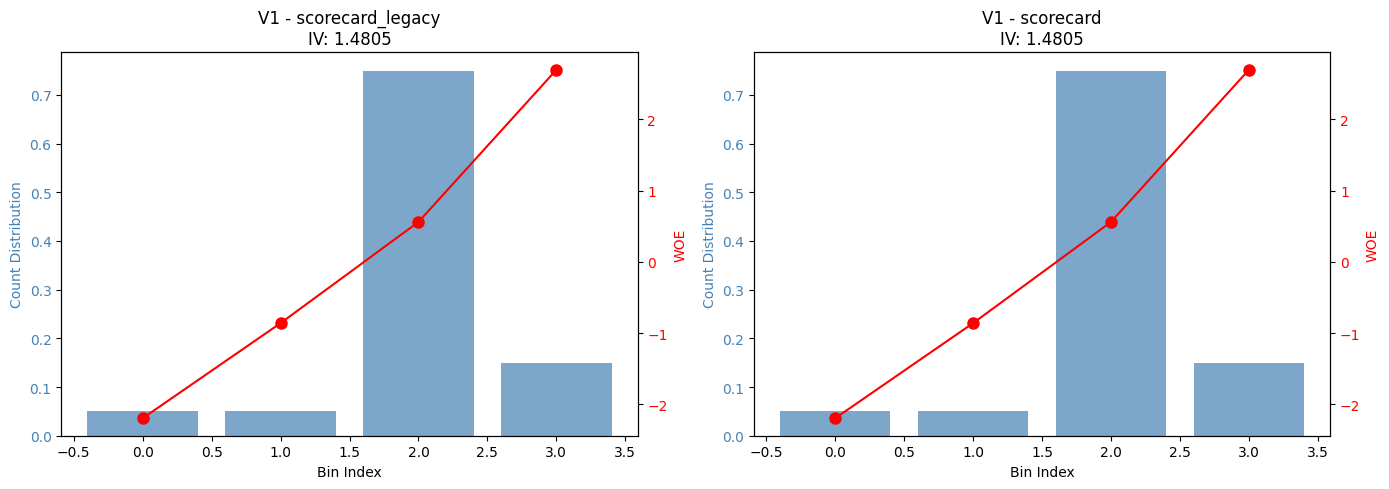

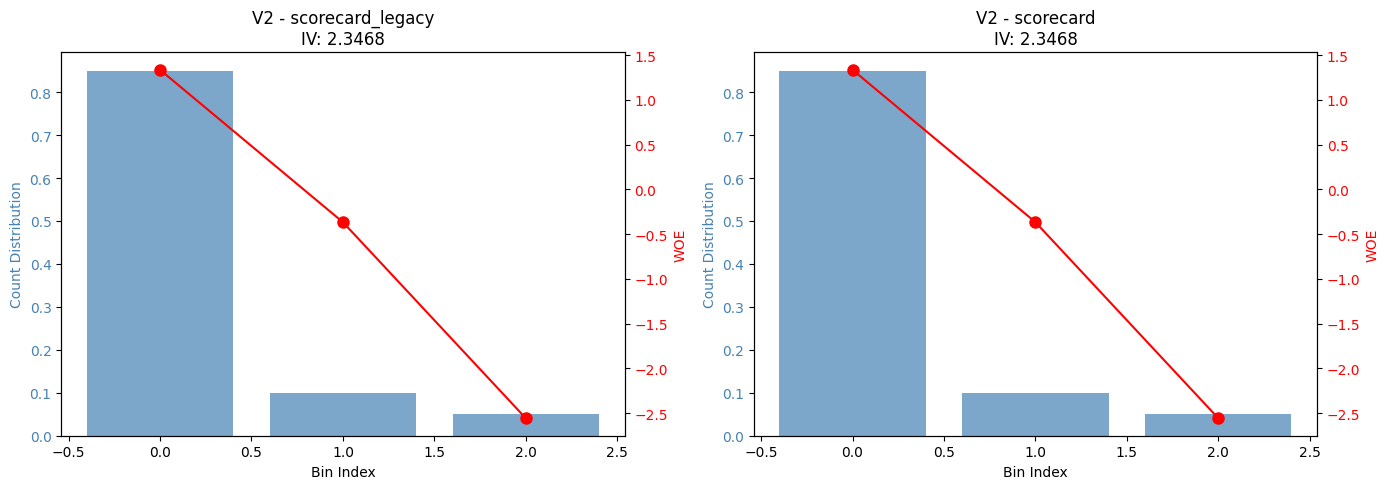

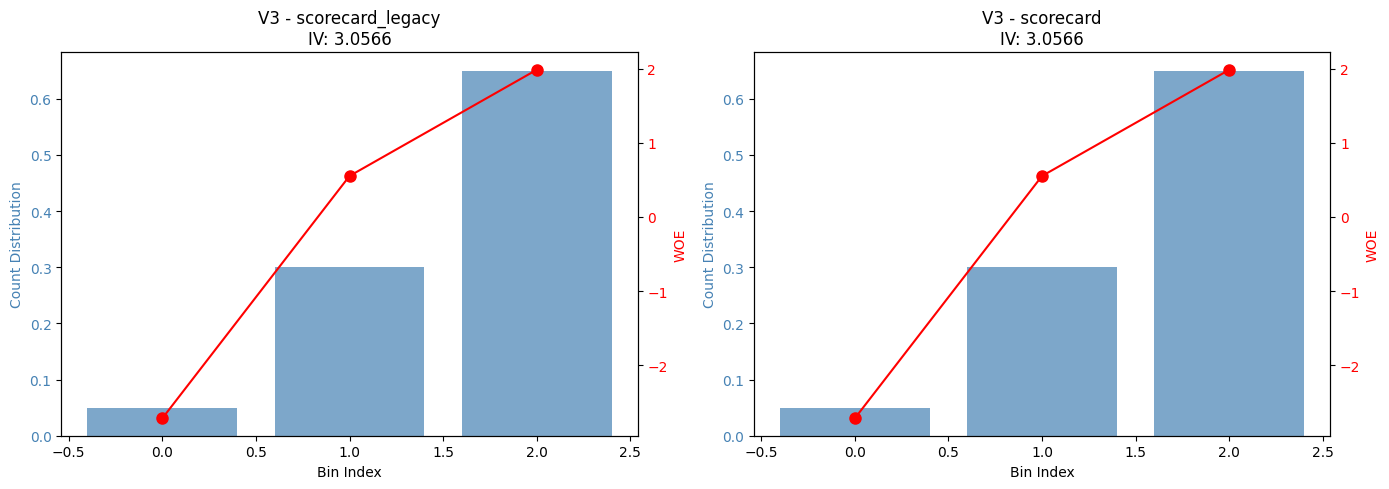

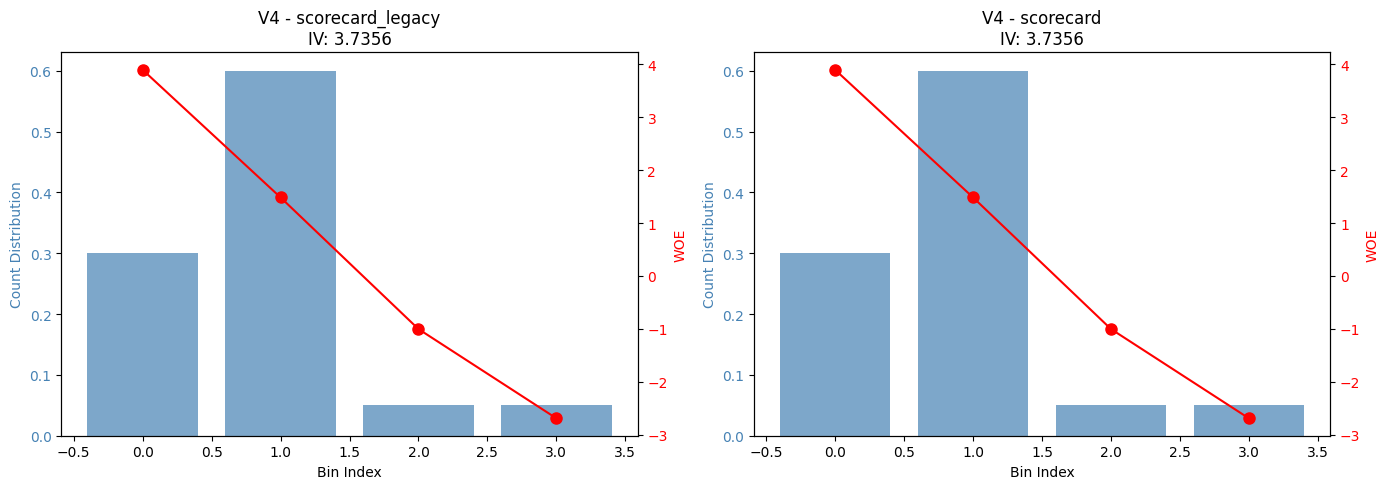

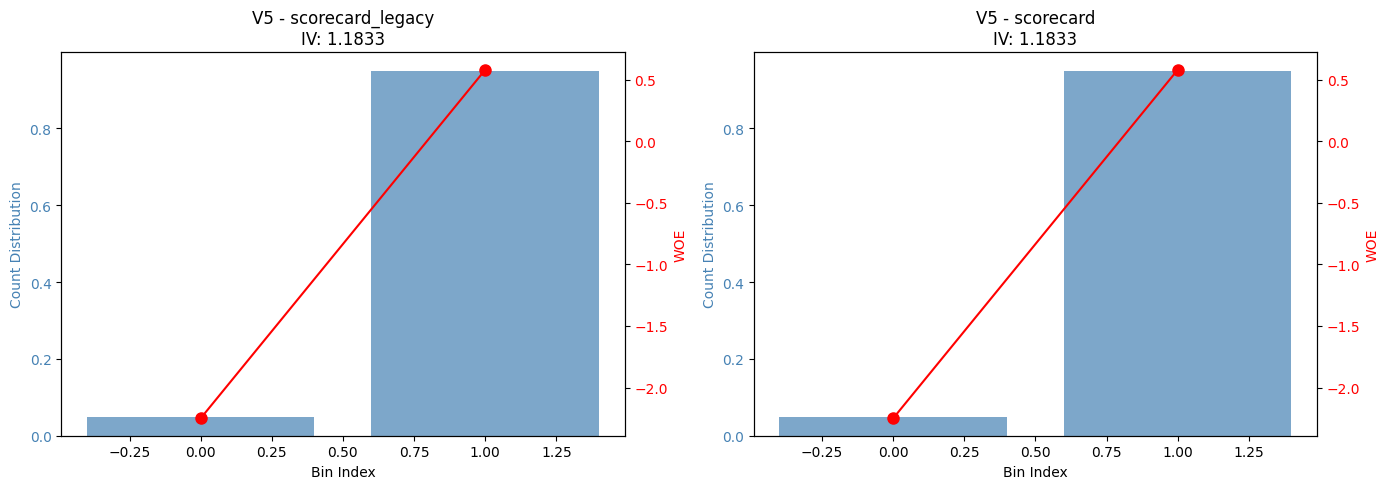

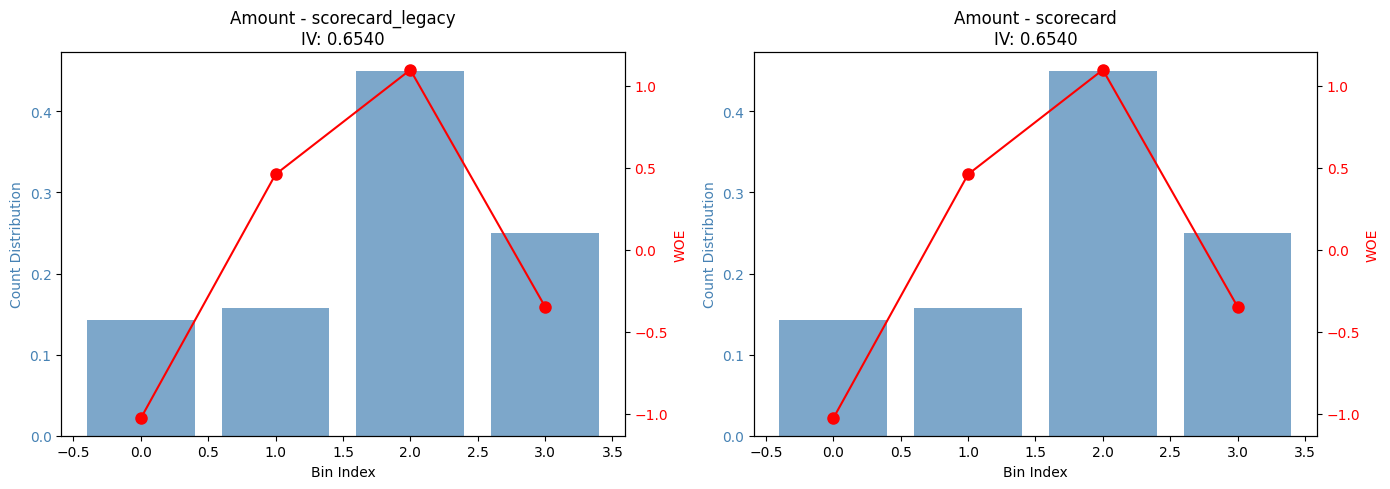

In [17]:
import matplotlib.pyplot as plt

def plot_woe_comparison(bins_legacy, bins_new, var_name):
    """绘制 WOE 对比图"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # legacy
    df_leg = bins_legacy[var_name].copy()
    df_leg = df_leg[~df_leg['is_special_values']].reset_index(drop=True)
    ax1 = axes[0]
    ax1.bar(range(len(df_leg)), df_leg['count_distr'], alpha=0.7, label='count_distr', color='steelblue')
    ax1.set_xlabel('Bin Index')
    ax1.set_ylabel('Count Distribution', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(range(len(df_leg)), df_leg['woe'], 'ro-', label='woe', markersize=8)
    ax1_twin.set_ylabel('WOE', color='red')
    ax1_twin.tick_params(axis='y', labelcolor='red')
    ax1.set_title(f'{var_name} - scorecard_legacy\nIV: {df_leg["total_iv"].iloc[0]:.4f}')
    
    # new
    df_new = bins_new[var_name].copy()
    df_new = df_new[~df_new['is_special_values']].reset_index(drop=True)
    ax2 = axes[1]
    ax2.bar(range(len(df_new)), df_new['count_distr'], alpha=0.7, label='count_distr', color='steelblue')
    ax2.set_xlabel('Bin Index')
    ax2.set_ylabel('Count Distribution', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    
    ax2_twin = ax2.twinx()
    ax2_twin.plot(range(len(df_new)), df_new['woe'], 'ro-', label='woe', markersize=8)
    ax2_twin.set_ylabel('WOE', color='red')
    ax2_twin.tick_params(axis='y', labelcolor='red')
    ax2.set_title(f'{var_name} - scorecard\nIV: {df_new["total_iv"].iloc[0]:.4f}')
    
    plt.tight_layout()
    plt.show()

for var in features:
    plot_woe_comparison(bins_legacy, bins_new, var)

## 6. 总结

In [18]:
print("="*60)
print("分箱对比总结")
print("="*60)

print("\n1. IV 值对比:")
print(f"   - 各变量 IV 值差异很小，最大差异: {iv_compare['IV_diff'].abs().max():.6f}")

print("\n2. 分箱数量对比:")
print(f"   - legacy 总分箱数: {bin_count_compare['bins_legacy'].sum()}")
print(f"   - new 总分箱数: {bin_count_compare['bins_new'].sum()}")

print("\n3. 关键结论:")
if iv_compare['IV_diff'].abs().max() < 0.001:
    print("   ✓ scorecard 模块与 scorecard_legacy 模块分箱结果高度一致")
else:
    print("   ⚠ 两个模块分箱结果存在差异，需要进一步检查")

print("\n4. 模块差异说明:")
print("   - scorecard_legacy: 单文件实现，包含完整的分箱逻辑")
print("   - scorecard: 模块化设计，更好的扩展性和代码组织")

分箱对比总结

1. IV 值对比:
   - 各变量 IV 值差异很小，最大差异: 0.000000

2. 分箱数量对比:
   - legacy 总分箱数: 20
   - new 总分箱数: 20

3. 关键结论:
   ✓ scorecard 模块与 scorecard_legacy 模块分箱结果高度一致

4. 模块差异说明:
   - scorecard_legacy: 单文件实现，包含完整的分箱逻辑
   - scorecard: 模块化设计，更好的扩展性和代码组织
